In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import os

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
df = pd.read_csv(os.path.join(BASE_DIR, '../data/career_data.csv'), sep='\t')
print(f"Dataset loaded: {df.shape[0]} careers, {df.shape[1]} columns")
df.head()

Dataset loaded: 167 careers, 20 columns


,interest_coding,interest_design,interest_science,interest_art,interest_cooking,interest_travel,interest_business,math_skill,creativity,communication,introvert_extrovert,problem_solving,interest_technology,interest_writing,interest_music,interest_helping_others,leadership,attention_to_detail,physical_stamina,career
0,5,2,4,1,1,1,3,5,3,2,1,5,5,2,1,1,2,4,1,Software Engineer
1,5,1,5,1,1,1,3,5,3,2,1,5,5,1,1,1,2,4,1,Data Scientist
2,5,2,4,1,1,1,4,5,3,3,2,5,5,2,1,1,3,5,1,Data Analyst
3,5,2,5,1,1,1,3,5,4,2,1,5,5,2,1,1,2,4,1,AI Engineer
4,5,1,5,1,1,1,3,5,4,2,1,5,5,1,1,1,2,4,1,Machine Learning Engineer


In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (167, 20)

Data Types:
interest_coding             int64
interest_design             int64
interest_science            int64
interest_art                int64
interest_cooking            int64
interest_travel             int64
interest_business           int64
math_skill                  int64
creativity                  int64
communication               int64
introvert_extrovert         int64
problem_solving             int64
interest_technology         int64
interest_writing            int64
interest_music              int64
interest_helping_others     int64
leadership                  int64
attention_to_detail         int64
physical_stamina            int64
career                     object
dtype: object

Missing Values:
interest_coding            0
interest_design            0
interest_science           0
interest_art               0
interest_cooking           0
interest_travel            0
interest_business          0
math_skill                 0
creativity                 

,interest_coding,interest_design,interest_science,interest_art,interest_cooking,interest_travel,interest_business,math_skill,creativity,communication,introvert_extrovert,problem_solving,interest_technology,interest_writing,interest_music,interest_helping_others,leadership,attention_to_detail,physical_stamina
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,2.281437,2.203593,3.197605,2.137725,1.095808,2.107784,3.221557,3.550898,3.389222,3.610778,2.449102,4.185629,3.526946,2.532934,1.562874,2.311377,2.790419,4.155689,1.814371
std,1.246132,1.377701,1.410970,1.426581,0.551379,1.058699,1.020283,1.287843,1.171192,1.201657,1.215654,0.861651,1.010871,1.279045,0.847000,1.330387,1.139818,0.760279,1.101055
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
25%,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,4.000000,1.000000
50%,2.000000,2.000000,3.000000,1.000000,1.000000,2.000000,3.000000,4.000000,3.000000,4.000000,2.000000,4.000000,3.000000,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,4.000000,5.000000,5.000000,5.000000,3.000000,5.000000,4.000000,4.000000,2.000000,3.000000,4.000000,5.000000,2.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [4]:
print("Checking all scores are between 1 and 5:")
for col in df.columns[:-1]:
    if not df[col].between(1, 5).all():
        print(f"  Invalid values in {col}")
    else:
        print(f"  {col} ✓")

print(f"\nDuplicate careers: {df['career'].duplicated().sum()}")

Checking all scores are between 1 and 5:
  interest_coding ✓
  interest_design ✓
  interest_science ✓
  interest_art ✓
  interest_cooking ✓
  interest_travel ✓
  interest_business ✓
  math_skill ✓
  creativity ✓
  communication ✓
  introvert_extrovert ✓
  problem_solving ✓
  interest_technology ✓
  interest_writing ✓
  interest_music ✓
  interest_helping_others ✓
  leadership ✓
  attention_to_detail ✓
  physical_stamina ✓

Duplicate careers: 0


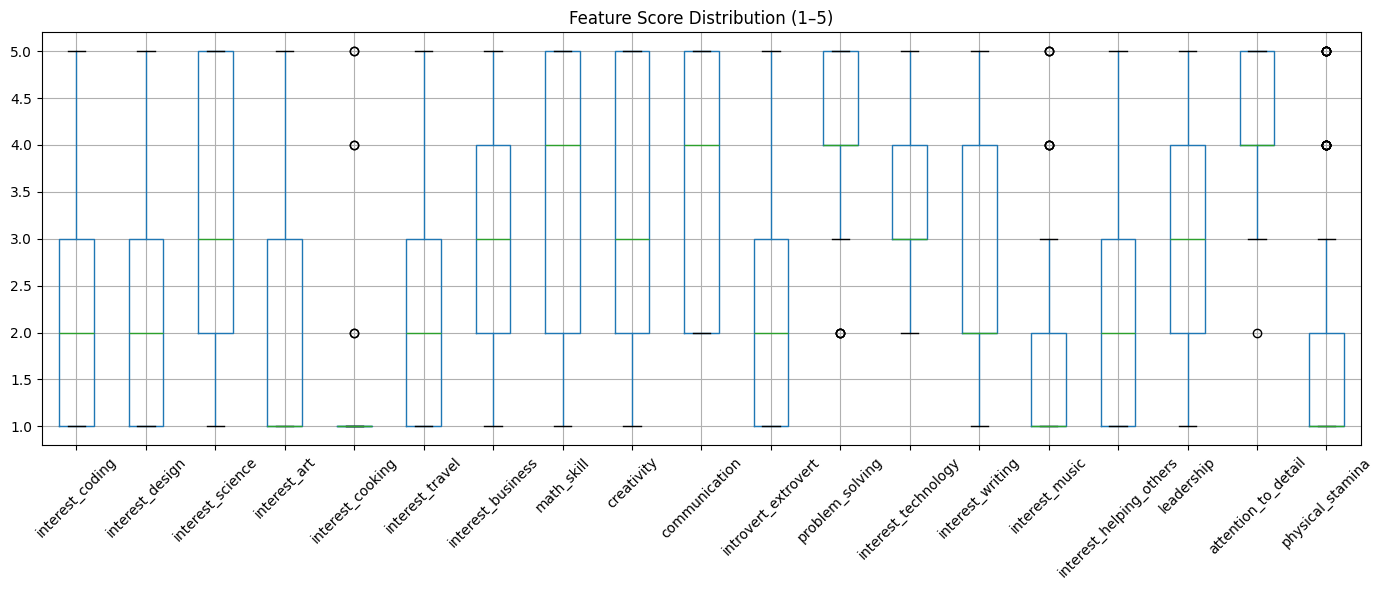

In [5]:
plt.figure(figsize=(14, 6))
df.drop("career", axis=1).boxplot(rot=45)
plt.title("Feature Score Distribution (1–5)")
plt.tight_layout()
plt.show()

In [6]:
X = df.drop("career", axis=1)
y = df["career"]
print("Feature columns:", X.columns.tolist())
print("Number of careers:", len(y))

Feature columns: ['interest_coding', 'interest_design', 'interest_science', 'interest_art', 'interest_cooking', 'interest_travel', 'interest_business', 'math_skill', 'creativity', 'communication', 'introvert_extrovert', 'problem_solving', 'interest_technology', 'interest_writing', 'interest_music', 'interest_helping_others', 'leadership', 'attention_to_detail', 'physical_stamina']
Number of careers: 167


In [7]:
# Sample input with all 19 features
new_input = pd.DataFrame({
    'interest_coding': [4],
    'interest_design': [2],
    'interest_science': [4],
    'interest_art': [1],
    'interest_cooking': [1],
    'interest_travel': [2],
    'interest_business': [3],
    'math_skill': [4],
    'creativity': [4],
    'communication': [4],
    'introvert_extrovert': [3],
    'problem_solving': [5],
    'interest_technology': [5],
    'interest_writing': [2],
    'interest_music': [1],
    'interest_helping_others': [2],
    'leadership': [3],
    'attention_to_detail': [5],
    'physical_stamina': [1]
})

# Ensure column order matches dataset
new_input = new_input[X.columns]

# Compute similarity
similarity_scores = cosine_similarity(new_input, X)[0]

# Use copy to avoid modifying global df
results = df.copy()
results["similarity"] = similarity_scores
top5 = results.sort_values(by="similarity", ascending=False).head(5)

print("Top 5 Recommended Careers:")
print(top5[["career", "similarity"]])

Top 5 Recommended Careers:
                   career  similarity
27           Risk Analyst    0.980341
2            Data Analyst    0.980198
23          IT Consultant    0.978384
128   Health Data Analyst    0.978068
6    System Administrator    0.975791


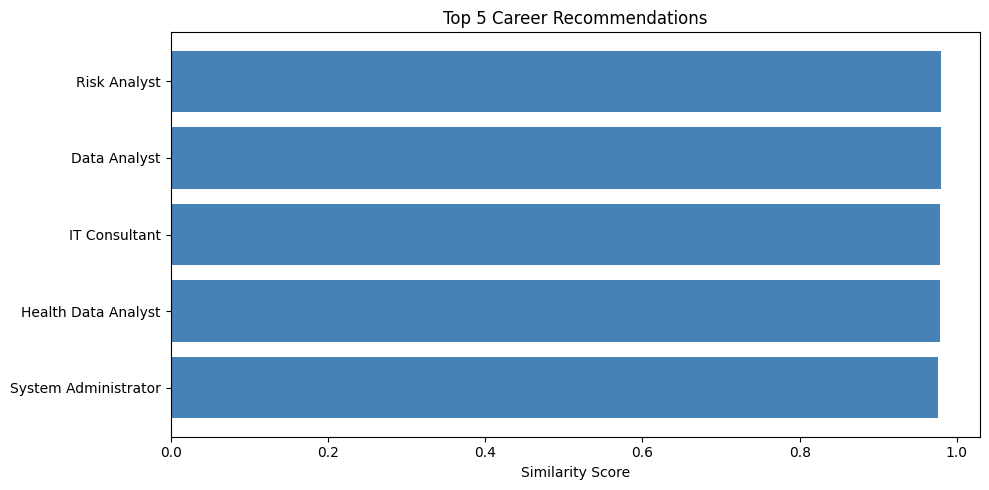

In [8]:
plt.figure(figsize=(10, 5))
plt.barh(top5["career"], top5["similarity"], color="steelblue")
plt.xlabel("Similarity Score")
plt.title("Top 5 Career Recommendations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()